# Diabetic Retinopathy - Model Training (Transfer Learning)


We will use **EfficientNetB3**, which is highly effective for image classification tasks, including medical images like retinal scans.


In [1]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install tensorflow

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.21.0


## 1. Load Data and Split


In [4]:
# Load CSV
df = pd.read_csv("train.csv")

# Map diagnosis to class names for the generator
class_names = {0: "No_DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferate_DR"}
df["class_name"] = df["diagnosis"].map(class_names)

# Ensure image paths point to the PREPROCESSED images
# Let's rebuild the paths based on the previous preprocessing notebook logic
image_dir = "colored_images_preprocessed"
extensions = [".png", ".jpg", ".jpeg"]

def get_path(row):
    for ext in extensions:
        # Check class folder
        path = os.path.join(image_dir, row["class_name"], row["id_code"] + ext)
        if os.path.exists(path):
            return path
    return None

df["image_path"] = df.apply(get_path, axis=1)

# Drop any rows where the image wasn't found (just in case)
missing = df["image_path"].isna().sum()
print(f"Missing images: {missing}")
df = df.dropna(subset=["image_path"])

# Data Split: 70% Train, 10% Validation, 20% Test
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["diagnosis"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=1/3, stratify=temp_df["diagnosis"], random_state=42)

print(f"Train: {train_df.shape[0]} | Validation: {val_df.shape[0]} | Test: {test_df.shape[0]}")


Missing images: 0
Train: 2563 | Validation: 732 | Test: 367


## 2. Data Generators & Augmentation


In [5]:
TARGET_SIZE = 224 # EfficientNetB3 optimal size can be up to 300, 224 is a good starting point for speed/memory
BATCH_SIZE = 32

# Augmentation for training only
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="constant", cval=0,
    # EfficientNet expects inputs to be unscaled or scaled depending on the specific Keras implementation.
    # tf.keras.applications.efficientnet handles its own scaling internally! So we don't use rescale=1./255
)

# No augmentation for val/test
val_test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_dataframe(
    train_df, x_col="image_path", y_col="class_name",
    target_size=(TARGET_SIZE, TARGET_SIZE), batch_size=BATCH_SIZE, class_mode="categorical", shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df, x_col="image_path", y_col="class_name",
    target_size=(TARGET_SIZE, TARGET_SIZE), batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    test_df, x_col="image_path", y_col="class_name",
    target_size=(TARGET_SIZE, TARGET_SIZE), batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False
)


Found 2563 validated image filenames belonging to 5 classes.
Found 732 validated image filenames belonging to 5 classes.
Found 367 validated image filenames belonging to 5 classes.


## 3. Handle Class Imbalance (Class Weights)


In [6]:
# Calculate class weights to penalize the model more for missing minority classes like Severe/Proliferate
classes = np.sort(train_df["diagnosis"].unique())
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_df["diagnosis"])
class_weights = dict(enumerate(weights))

print("Class Weights:")
for c, w in class_weights.items():
    print(f"Class {c} ({class_names[c]}): {w:.2f}")


Class Weights:
Class 0 (No_DR): 0.41
Class 1 (Mild): 1.98
Class 2 (Moderate): 0.73
Class 3 (Severe): 3.80
Class 4 (Proliferate_DR): 2.48


## 4. Model Building (EfficientNetB3)


In [7]:
# Load EfficientNetB3 without the top classification layer
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(TARGET_SIZE, TARGET_SIZE, 3))

# Freeze the base model layers (we only want to train the new top layers first)
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x) # Dropout to prevent overfitting
predictions = Dense(5, activation='softmax')(x) # 5 classes

model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 10,791,220 (41.17 MB)

 Trainable params: 7,685 (30.02 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

## 5. Training


In [8]:
# Setup Callbacks
checkpoint = ModelCheckpoint("best_efficientnet_model.keras", monitor="val_loss", save_best_only=True, mode="min", verbose=1)
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)

EPOCHS = 20

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr]
)


Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.6071 - loss: 1.5726
Epoch 1: val_loss improved from None to 0.93635, saving model to best_efficientnet_model.keras

Epoch 1: finished saving model to best_efficientnet_model.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 77s 844ms/step - accuracy: 0.6071 - loss: 1.5726 - val_accuracy: 0.7090 - val_loss: 0.9363 - learning_rate: 0.0010
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.6812 - loss: 1.3126
Epoch 2: val_loss improved from 0.93635 to 0.88778, saving model to best_efficientnet_model.keras

Epoch 2: finished saving model to best_efficientnet_model.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 67s 826ms/step - accuracy: 0.6812 - loss: 1.3126 - val_accuracy: 0.7104 - val_loss: 0.8878 - learning_rate: 0.0010
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - accuracy: 0.7031 - loss: 1.2310
Epoch 3: val_loss improved from 0.88778 to 0.83765, saving model to best_efficientnet_model.keras

Epoch 3: finished saving model to be

## 6. Evaluation


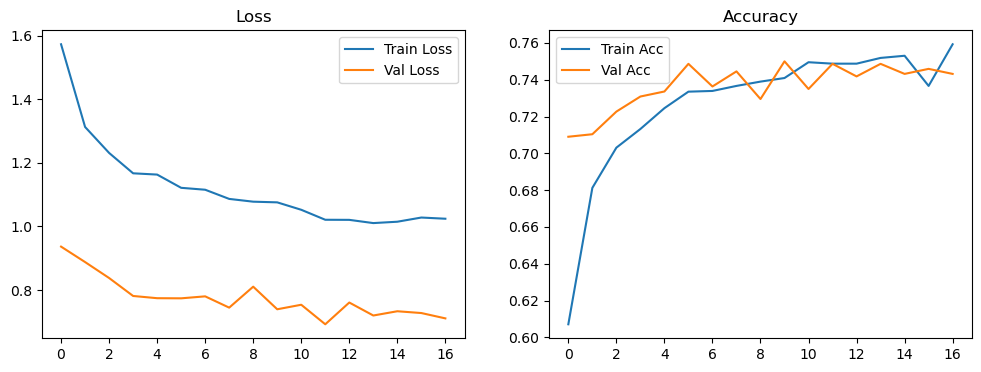

In [9]:
# Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()


In [10]:
# Evaluate on Test Set
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc*100:.2f}%")


12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 569ms/step - accuracy: 0.7738 - loss: 0.6698
Test Accuracy: 77.38%


12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 763ms/step
Classification Report:
                precision    recall  f1-score   support

          Mild       0.67      0.05      0.10        37
      Moderate       0.64      0.85      0.73       100
         No_DR       0.93      0.97      0.95       181
Proliferate_DR       0.50      0.57      0.53        30
        Severe       0.44      0.21      0.29        19

      accuracy                           0.77       367
     macro avg       0.64      0.53      0.52       367
  weighted avg       0.77      0.77      0.74       367



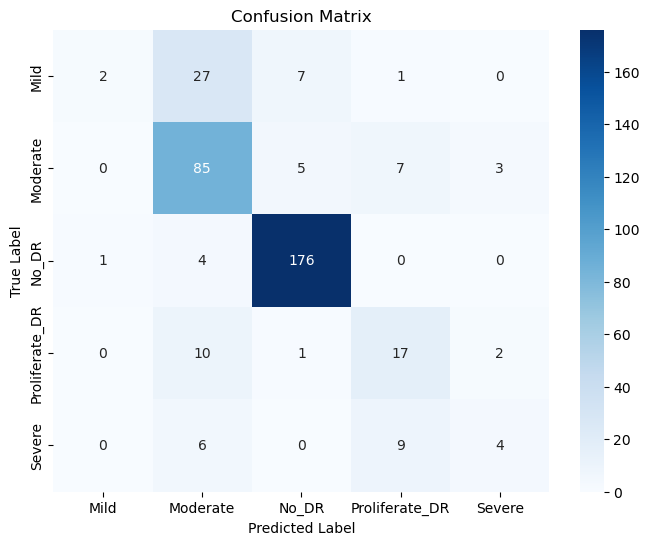

In [11]:
# Confusion Matrix & Classification Report
test_generator.reset()
preds = model.predict(test_generator)
pred_classes = np.argmax(preds, axis=1)
true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print("Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
